In [1]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Compute cosine similarity matrix between all gradient results
import torch.nn.functional as F

In [43]:
from analysis.utils import load_sweep_metadata, load_data
from analysis.utils import reconstruct_cartpole_dmcontrol

In [108]:
## UTILS


def fit_rastermap(data,
                  n_PCs=200,
                  n_clusters=100,
                  locality=0.75,
                  time_lag_window=10):
    """Fit Rastermap model to data and return embedding results."""
    from rastermap import Rastermap
    model = Rastermap(n_PCs=n_PCs,
                      n_clusters=n_clusters,
                      locality=locality,
                      time_lag_window=time_lag_window).fit(data)

    y = model.embedding  # neurons x 1
    isort = model.isort
    # visualize binning over neurons
    X_embedding = model.X_embedding

    return model, y, isort, X_embedding

In [13]:
df_metadata = load_sweep_metadata(
    ["logs/25-12-09-cartpole_initial_conditions_seeds_models"],
    json_file_name="episode_metadata.json")
df_metadata = df_metadata[df_metadata['checkpoint'] ==
                          'ckpts/cartpole-swingup-3.pt']
df = load_data(df_metadata,
               cart_position=[0],
               episode_file_name="episode_data.pkl")

Dirs in logs/25-12-09-cartpole_initial_conditions_seeds_models:   0%|          | 0/825 [00:00<?, ?it/s]

Dirs in logs/25-12-09-cartpole_initial_conditions_seeds_models: 100%|██████████| 825/825 [00:00<00:00, 11219.73it/s]


Found 825 configurations
Found 55 configurations


100%|██████████| 55/55 [00:00<00:00, 210.86it/s]


In [14]:
df['init_cart_position'] = df['initial_state'].apply(lambda x: x[0])
df['init_pole_angle'] = df['initial_state'].apply(lambda x: x[1])
df['init_pole_angle_degrees'] = np.degrees(df['init_pole_angle'])
df['init_pole_angle_str'] = df['init_pole_angle_degrees'].round(0).astype(str)


In [19]:
df.columns

Index(['seed', 'initial_state', 'checkpoint', 'task', 'task_name',
       'episode_idx', 'episode_length', 'total_reward', 'timestamp',
       'obs_type', 'directory', 'observations', 'actions', 'rewards', 'dones',
       'latent_states', 'timesteps', 'init_cart_position', 'init_pole_angle',
       'init_pole_angle_degrees', 'init_pole_angle_str'],
      dtype='object')

In [38]:
df['init_pole_angle_degrees'].unique()

array([360., 180., 108., 252.,   0.,  36., 216.,  72., 324., 144., 288.])

In [93]:
angle_to_plot = 180
data_to_plot = df[(df['init_pole_angle_degrees'] == angle_to_plot) &
                  (df['seed'] == 1)]

In [94]:
z = np.concatenate(data_to_plot['latent_states'].tolist())
actions = np.concatenate(data_to_plot['actions'].tolist())
observations = np.concatenate(data_to_plot['observations'].tolist())
rewards = np.concatenate(data_to_plot['rewards'].tolist())

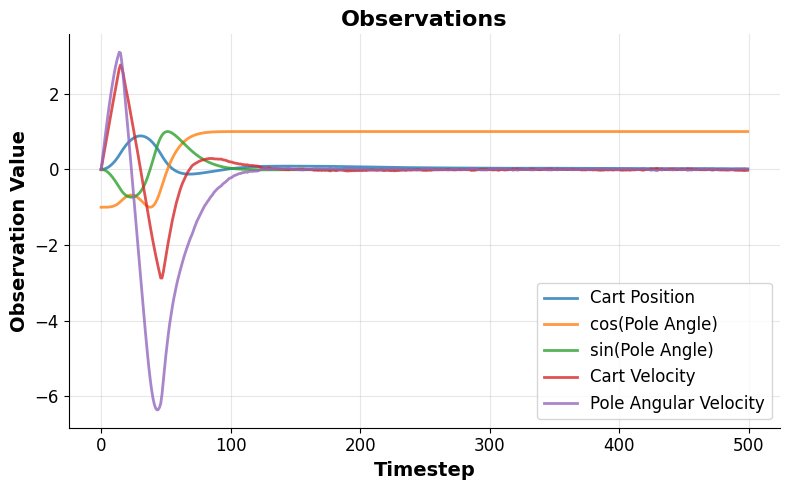

In [95]:
dim_names = {
    0: 'Cart Position',
    1: 'cos(Pole Angle)',
    2: 'sin(Pole Angle)',
    3: 'Cart Velocity',
    4: 'Pole Angular Velocity',
}

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# Plot observations
for dim in range(observations.shape[1]):
    ax.plot(observations[:, dim],
            linewidth=2,
            alpha=0.8,
            label=dim_names.get(dim, f'Dim {dim}'))
ax.set_xlabel('Timestep', fontsize=14, fontweight='bold')
ax.set_ylabel('Observation Value', fontsize=14, fontweight='bold')
ax.set_title('Observations', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=12)
sns.despine()
plt.tight_layout()
plt.show()

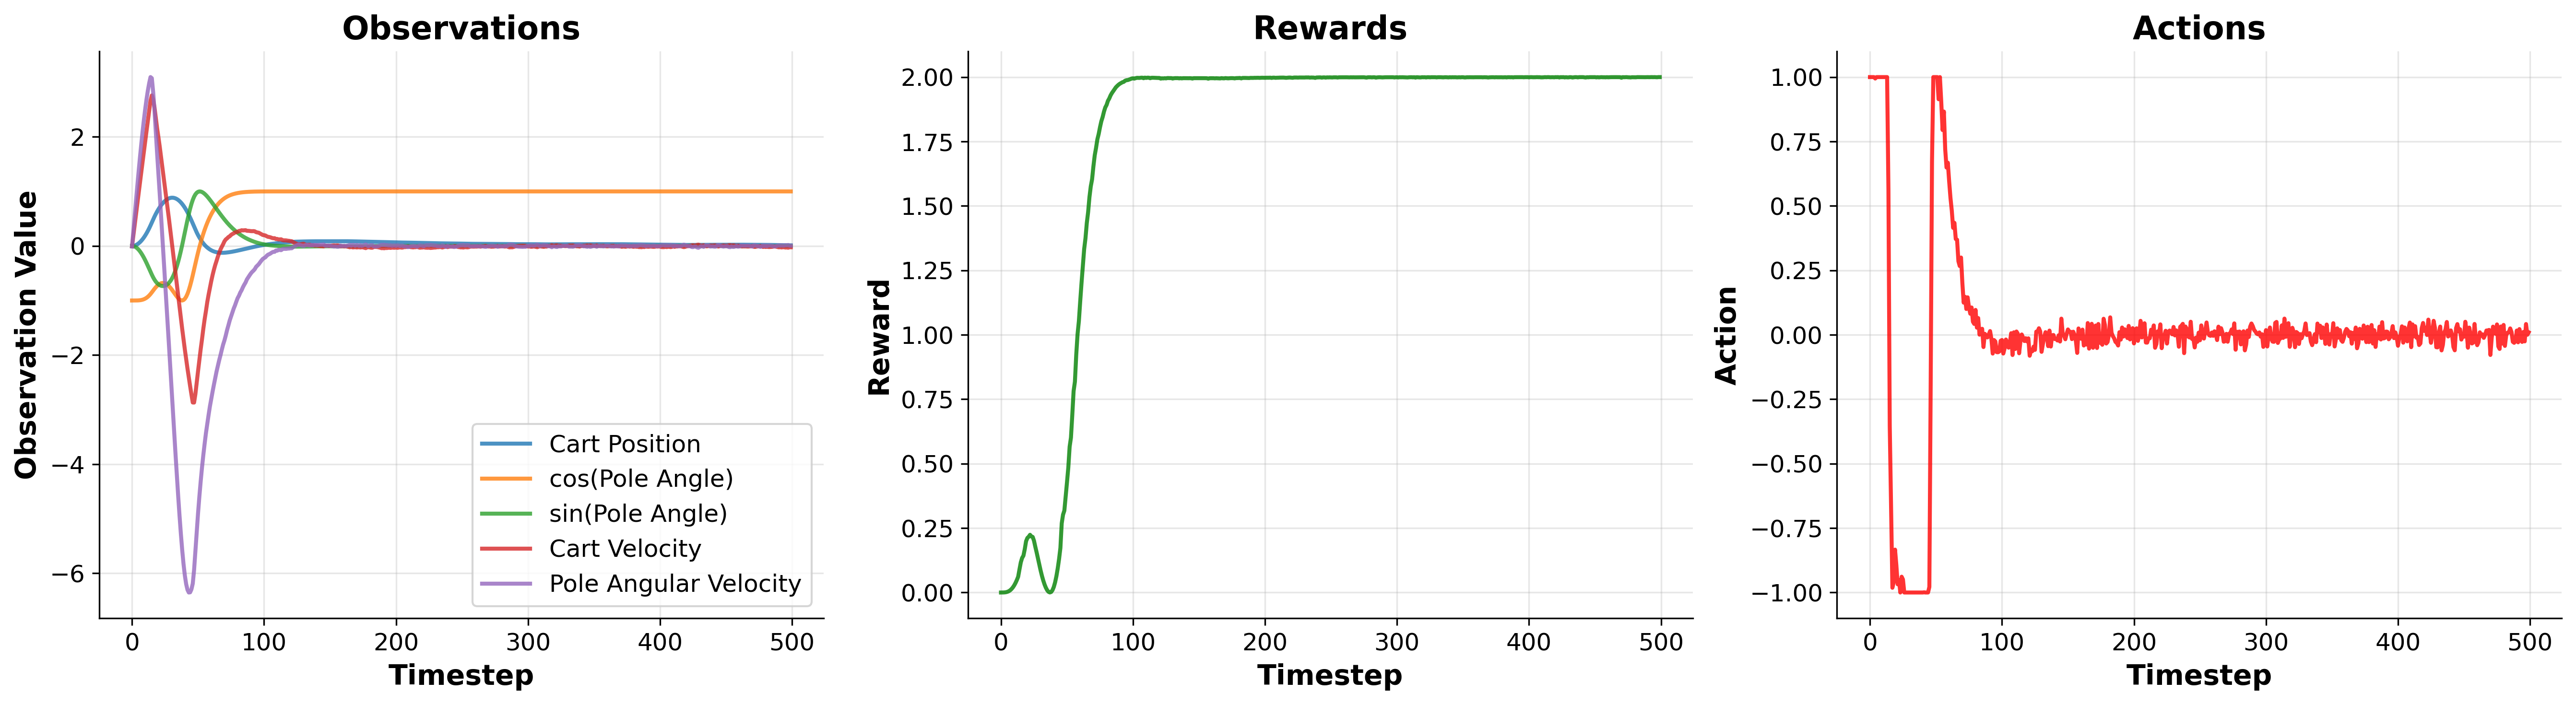

In [96]:
dim_names = {
    0: 'Cart Position',
    1: 'cos(Pole Angle)',
    2: 'sin(Pole Angle)',
    3: 'Cart Velocity',
    4: 'Pole Angular Velocity',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=300)

# Plot observations
ax = axes[0]
for dim in range(observations.shape[1]):
    ax.plot(observations[:, dim],
            linewidth=2,
            alpha=0.8,
            label=dim_names.get(dim, f'Dim {dim}'))
ax.set_xlabel('Timestep', fontsize=14, fontweight='bold')
ax.set_ylabel('Observation Value', fontsize=14, fontweight='bold')
ax.set_title('Observations', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=12)

# Plot rewards
ax = axes[1]
ax.plot(rewards, linewidth=2, alpha=0.8, color='green')
ax.set_xlabel('Timestep', fontsize=14, fontweight='bold')
ax.set_ylabel('Reward', fontsize=14, fontweight='bold')
ax.set_title('Rewards', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=12)

# Plot actions
ax = axes[2]
ax.plot(actions, linewidth=2, alpha=0.8, color='red')
ax.set_xlabel('Timestep', fontsize=14, fontweight='bold')
ax.set_ylabel('Action', fontsize=14, fontweight='bold')
ax.set_title('Actions', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=12)
sns.despine()
plt.tight_layout()
plt.show()


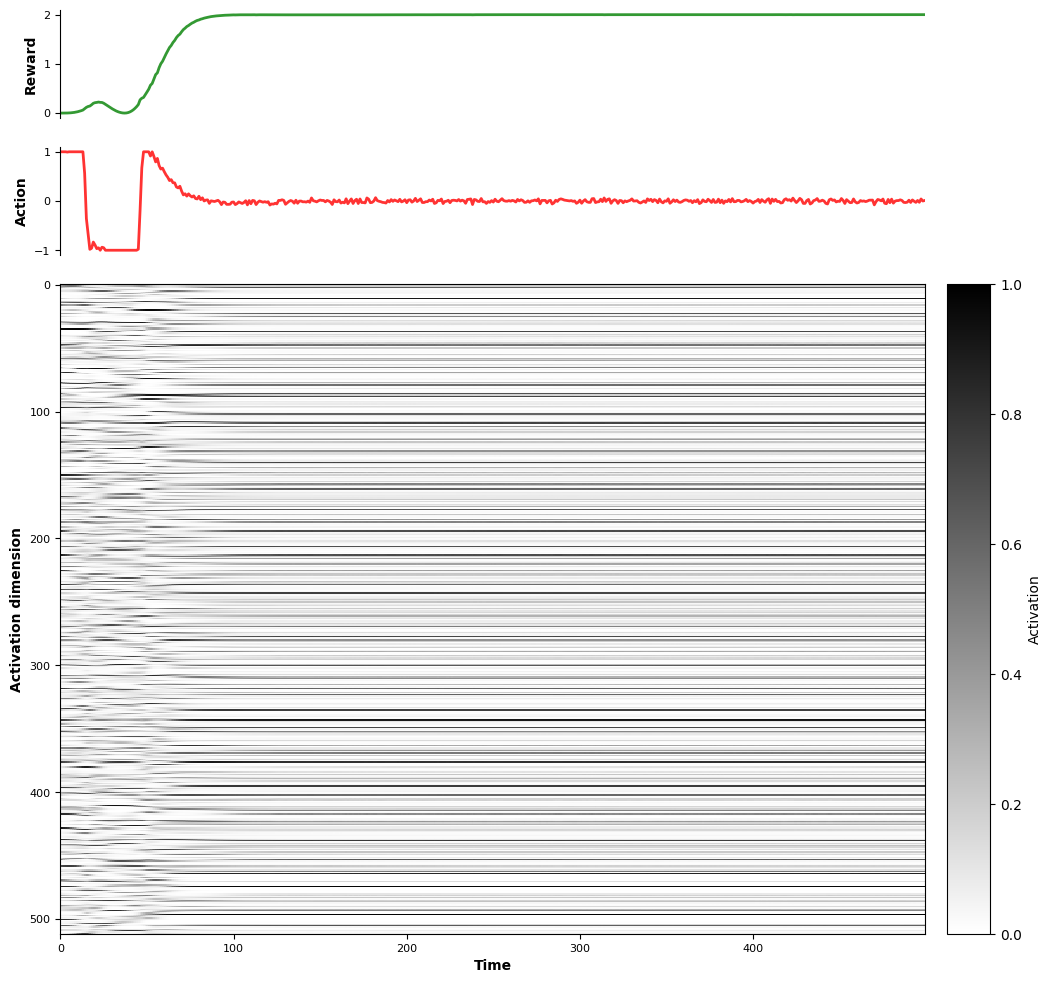

In [97]:
# Create a grid layout with latents on bottom and actions/rewards on top
fig = plt.figure(figsize=(12, 12))
gs = fig.add_gridspec(3,
                      2,
                      height_ratios=[1, 1, 6],
                      width_ratios=[20, 1],
                      hspace=0.1,
                      wspace=0.05)

# Plot rewards on top
ax_rewards = fig.add_subplot(gs[0, 0])
ax_rewards.plot(np.arange(len(rewards)),
                rewards,
                linewidth=2,
                alpha=0.8,
                color='green')
ax_rewards.set_ylabel('Reward', fontsize=10, fontweight='bold')
ax_rewards.set_xlim(0, len(rewards) - 1)
ax_rewards.tick_params(labelsize=8, labelbottom=False, bottom=False)
ax_rewards.spines['bottom'].set_visible(False)
ax_rewards.spines['left'].set_visible(True)
ax_rewards.spines['right'].set_visible(False)
ax_rewards.spines['top'].set_visible(False)

# Plot actions in middle
ax_actions = fig.add_subplot(gs[1, 0])
ax_actions.plot(np.arange(len(actions)),
                actions,
                linewidth=2,
                alpha=0.8,
                color='red')
ax_actions.set_ylabel('Action', fontsize=10, fontweight='bold')
ax_actions.set_xlim(0, len(actions) - 1)
ax_actions.tick_params(labelsize=8, labelbottom=False, bottom=False)
ax_actions.spines['bottom'].set_visible(False)
ax_actions.spines['left'].set_visible(True)
ax_actions.spines['right'].set_visible(False)
ax_actions.spines['top'].set_visible(False)

# Plot latents as imshow on bottom
ax_main = fig.add_subplot(gs[2, 0])
im = ax_main.imshow(z.T,
                    vmin=0,
                    vmax=1,
                    cmap="gray_r",
                    aspect="auto",
                    interpolation='none',
                    extent=[0, len(z) - 1, z.shape[1] - 0.5, -0.5])
ax_main.set_xlabel("Time", fontsize=10, fontweight='bold')
ax_main.set_ylabel("Activation dimension", fontsize=10, fontweight='bold')
ax_main.set_xlim(0, len(z) - 1)
#ax_main.set_title('Latent States', fontsize=12, fontweight='bold')
ax_main.tick_params(labelsize=8)

# Add colorbar for latents in the right column
cax = fig.add_subplot(gs[2, 1])
plt.colorbar(im, cax=cax, label='Activation')

plt.show()


## Fit Rastermap and plot results

In [109]:
model, y, isort, X_embedding = fit_rastermap(z.T)

2025-12-10 16:49:35,967 [INFO] normalizing data across axis=1
2025-12-10 16:49:35,969 [INFO] projecting out mean along axis=0
2025-12-10 16:49:36,062 [INFO] data normalized, 0.10sec
2025-12-10 16:49:36,062 [INFO] sorting activity: 512 valid samples by 500 timepoints
2025-12-10 16:49:36,275 [INFO] n_PCs = 200 computed, 0.31sec
2025-12-10 16:49:36,372 [INFO] 100 clusters computed, time 0.41sec
2025-12-10 16:50:26,451 [INFO] clusters sorted, time 50.48sec
2025-12-10 16:50:26,530 [INFO] clusters upsampled, time 50.56sec
2025-12-10 16:50:26,533 [INFO] rastermap complete, time 50.57sec


In [111]:
z_sorted = z[:, isort]

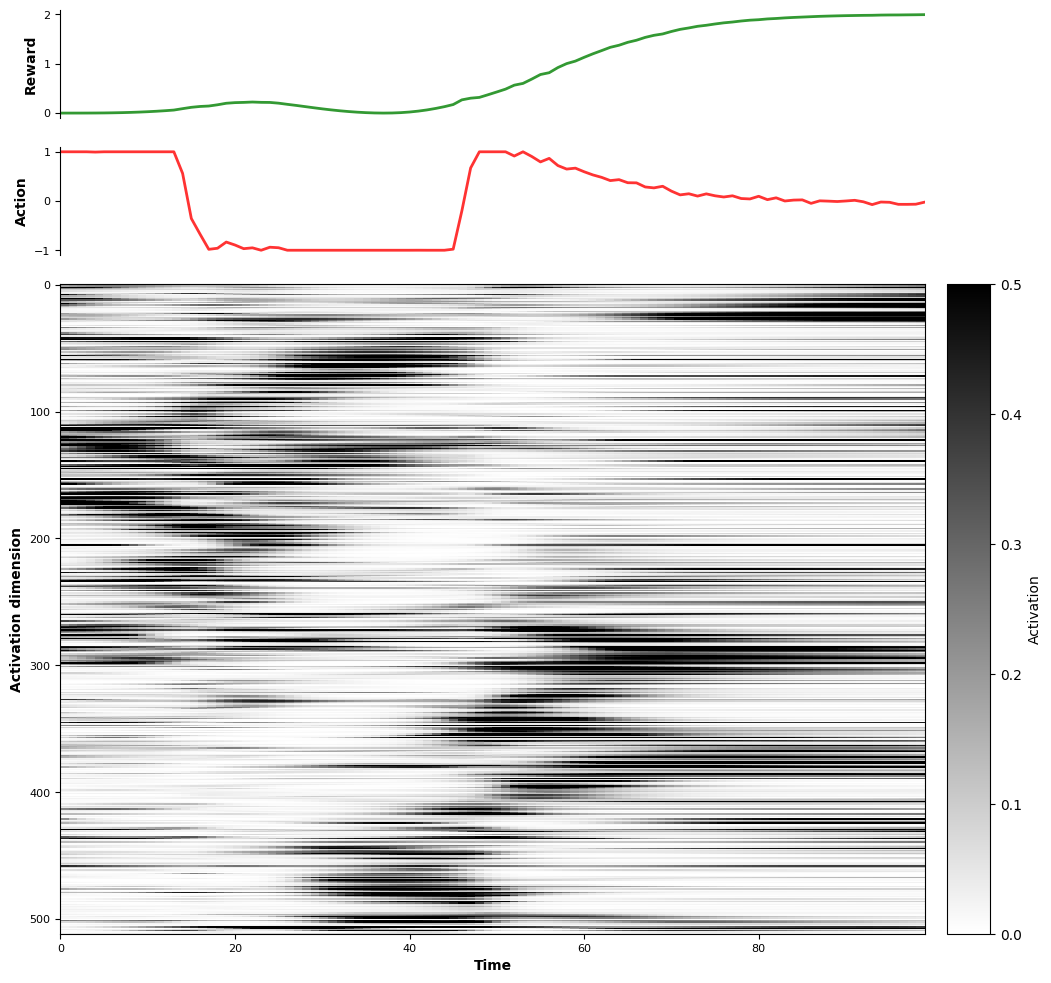

In [116]:
# Create a grid layout with latents on bottom and actions/rewards on top
time_points_to_plot = 100

rewards_to_plot = rewards[:time_points_to_plot]
actions_to_plot = actions[:time_points_to_plot]
z_sorted_to_plot = z_sorted[:time_points_to_plot]

fig = plt.figure(figsize=(12, 12))
gs = fig.add_gridspec(3,
                      2,
                      height_ratios=[1, 1, 6],
                      width_ratios=[20, 1],
                      hspace=0.1,
                      wspace=0.05)

# Plot rewards on top
ax_rewards = fig.add_subplot(gs[0, 0])
ax_rewards.plot(np.arange(len(rewards_to_plot)),
                rewards_to_plot,
                linewidth=2,
                alpha=0.8,
                color='green')
ax_rewards.set_ylabel('Reward', fontsize=10, fontweight='bold')
ax_rewards.set_xlim(0, len(rewards_to_plot) - 1)
ax_rewards.tick_params(labelsize=8, labelbottom=False, bottom=False)
ax_rewards.spines['bottom'].set_visible(False)
ax_rewards.spines['left'].set_visible(True)
ax_rewards.spines['right'].set_visible(False)
ax_rewards.spines['top'].set_visible(False)

# Plot actions in middle
ax_actions = fig.add_subplot(gs[1, 0])
ax_actions.plot(np.arange(len(actions_to_plot)),
                actions_to_plot,
                linewidth=2,
                alpha=0.8,
                color='red')
ax_actions.set_ylabel('Action', fontsize=10, fontweight='bold')
ax_actions.set_xlim(0, len(actions_to_plot) - 1)
ax_actions.tick_params(labelsize=8, labelbottom=False, bottom=False)
ax_actions.spines['bottom'].set_visible(False)
ax_actions.spines['left'].set_visible(True)
ax_actions.spines['right'].set_visible(False)
ax_actions.spines['top'].set_visible(False)

# Plot latents as imshow on bottom
ax_main = fig.add_subplot(gs[2, 0])
im = ax_main.imshow(z_sorted_to_plot.T,
                    vmin=0,
                    vmax=0.5,
                    cmap="gray_r",
                    aspect="auto",
                    interpolation='none',
                    extent=[
                        0,
                        len(z_sorted_to_plot) - 1,
                        z_sorted_to_plot.shape[1] - 0.5, -0.5
                    ])
ax_main.set_xlabel("Time", fontsize=10, fontweight='bold')
ax_main.set_ylabel("Activation dimension", fontsize=10, fontweight='bold')
ax_main.set_xlim(0, len(z_sorted_to_plot) - 1)
#ax_main.set_title('Latent States', fontsize=12, fontweight='bold')
ax_main.tick_params(labelsize=8)

# Add colorbar for latents in the right column
cax = fig.add_subplot(gs[2, 1])
plt.colorbar(im, cax=cax, label='Activation')

plt.show()

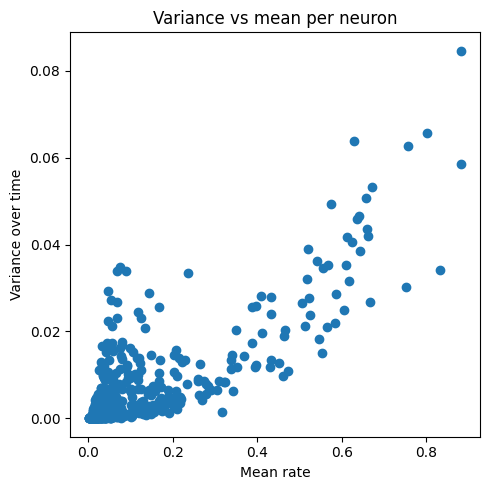

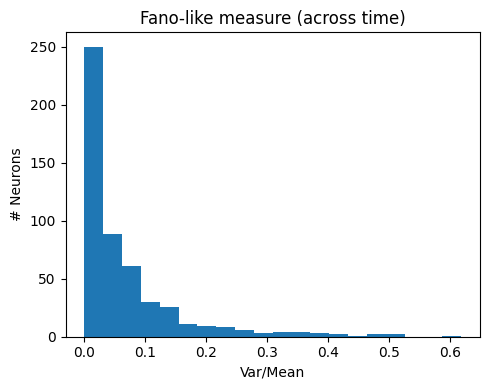

In [ ]:
import zipapp

mean_rates = z.mean(axis=0)  # (D,)
var_rates = z.var(axis=0)  # (D,)
fano_like = var_rates / (mean_rates + 1e-9)

plt.figure(figsize=(5, 5))
plt.scatter(mean_rates, var_rates)
plt.xlabel('Mean rate')
plt.ylabel('Variance over time')
plt.title('Variance vs mean per neuron')
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.hist(fano_like, bins=20)
plt.xlabel('Var/Mean')
plt.ylabel('# Neurons')
plt.title('Fano-like measure (across time)')
plt.tight_layout()
plt.show()

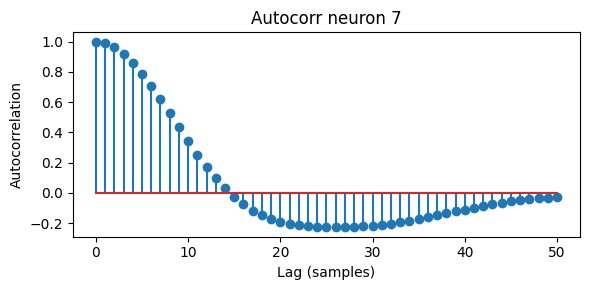

In [106]:
def autocorr(x, max_lag):
    x = x - x.mean()
    result = np.correlate(x, x, mode='full')
    mid = len(result) // 2
    ac = result[mid:mid + max_lag + 1]
    return ac / ac[0]


max_lag = 50  # samples
example_neuron = 7

ac = autocorr(z[:, example_neuron], max_lag)

plt.figure(figsize=(6, 3))
lags = np.arange(max_lag + 1)
plt.stem(lags, ac)
plt.xlabel('Lag (samples)')
plt.ylabel('Autocorrelation')
plt.title(f'Autocorr neuron {example_neuron}')
plt.tight_layout()
plt.show()
